In [1]:
#DATA INGESTION

#Importing the dataset and printing the first 5 rows using head func
import pandas as pd
df = pd.read_csv(
    r"C:\Users\yoshi\Downloads\PandasAssignment\household_power_consumption.txt",
    sep=";"
)

C:\Users\yoshi\AppData\Local\Temp\ipykernel_7492\3863594366.py:5: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
#Adding timestamp 
#Initially only used DataFrame methods then used datetime func to turn into objects so python can undertsand it 
#Also learnt formatting here

df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"],format="%d/%m/%Y %H:%M:%S")
print(df.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  \
0           18.400          0.000          1.000            17.0   
1           23.000          0.000          1.000            16.0   
2           23.000          0.000          2.000            17.0   
3           23.000          0.000          1.000            17.0   
4           15.800          0.000          1.000            17.0   

            timestamp  
0 2006-12-16 17:24:00  
1 2006-12-16 17:25:00  
2 2006-12-16 17:26:00  
3 2006-12-16 17:27:00  
4 

In [3]:
#before removing NULL vals, checking missing mixed values as per wrning initially
print((df == "?").sum())

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3               0
timestamp                    0
dtype: int64


In [4]:
#Checking data set size to verify after cleaning up
print(df.shape)

(2075259, 10)


In [5]:
df = df.replace("?", pd.NA) #turn missing to Null
df = df.dropna()

print(df.shape)  #check if we got rid of the null vals

(2049280, 10)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    object        
 3   Global_reactive_power  object        
 4   Voltage                object        
 5   Global_intensity       object        
 6   Sub_metering_1         object        
 7   Sub_metering_2         object        
 8   Sub_metering_3         float64       
 9   timestamp              datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 172.0+ MB
None


In [7]:
#Had to fix data types to run aggregate funcs more easily
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"])
df["Global_reactive_power"] = pd.to_numeric(df["Global_reactive_power"])
df["Voltage"] = pd.to_numeric(df["Voltage"])
df["Global_intensity"] = pd.to_numeric(df["Global_intensity"])
df["Sub_metering_1"] = pd.to_numeric(df["Sub_metering_1"])
df["Sub_metering_2"] = pd.to_numeric(df["Sub_metering_2"])

In [8]:
#verifying the data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   timestamp              datetime64[ns]
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 172.0+ MB
None


In [9]:
import sys
print(sys.executable)

C:\Users\yoshi\anaconda3\envs\ml_env\python.exe


In [10]:
import sys
!{sys.executable} -m pip install pymongo

In [11]:
import pymongo
print(pymongo.__version__)

4.17.0


In [12]:
from pymongo import MongoClient
client = MongoClient("mongodb://localhost:27017")
print(client.list_database_names())

['admin', 'config', 'local', 'power_db']


In [13]:
db = client["power_db"]
collection = db["power_consumption"]
print(collection)

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'power_db'), 'power_consumption')


In [14]:
#new dataframe with 5 rows only rn
sample_df = df.head(5)

In [15]:
records = sample_df.to_dict("records")

In [16]:
#Convert to dictionary to be more compatibke to mongodb
records = sample_df.to_dict("records")

In [17]:
#Inserting into mongodb
result = collection.insert_many(records)

In [18]:
#Verifying if the insertion worked or nah
print(len(result.inserted_ids))

5


In [19]:
peak_row = df.loc[df["Global_active_power"].idxmax()]

print(peak_row["timestamp"])
print(peak_row["Global_active_power"])

2009-02-22 17:09:00
11.122


In [20]:
print(collection.count_documents({}))

9297145


In [21]:
#inserting the entire dataset/dataframe in batches
batch_size = 10000

for start in range(0, len(df), batch_size):
    batch = df.iloc[start:start + batch_size]
    records = batch.to_dict("records")
    collection.insert_many(records)
    print("Inserted:", start + len(batch))

Inserted: 10000
Inserted: 20000
Inserted: 30000
Inserted: 40000
Inserted: 50000
Inserted: 60000
Inserted: 70000
Inserted: 80000
Inserted: 90000
Inserted: 100000
Inserted: 110000
Inserted: 120000
Inserted: 130000
Inserted: 140000
Inserted: 150000
Inserted: 160000
Inserted: 170000
Inserted: 180000
Inserted: 190000
Inserted: 200000
Inserted: 210000
Inserted: 220000
Inserted: 230000
Inserted: 240000
Inserted: 250000
Inserted: 260000
Inserted: 270000
Inserted: 280000
Inserted: 290000
Inserted: 300000
Inserted: 310000
Inserted: 320000
Inserted: 330000
Inserted: 340000
Inserted: 350000
Inserted: 360000
Inserted: 370000
Inserted: 380000
Inserted: 390000
Inserted: 400000
Inserted: 410000
Inserted: 420000
Inserted: 430000
Inserted: 440000
Inserted: 450000
Inserted: 460000
Inserted: 470000
Inserted: 480000
Inserted: 490000
Inserted: 500000
Inserted: 510000
Inserted: 520000
Inserted: 530000
Inserted: 540000
Inserted: 550000
Inserted: 560000
Inserted: 570000
Inserted: 580000
Inserted: 590000
Insert

In [22]:
#checking insertion succes
print(collection.count_documents({}))

11346425


In [23]:
#PART 2
#finding the peak consumption
peak = collection.find_one(
    sort=[("Global_active_power", -1)]
)

print("Timestamp:", peak["timestamp"])
print("Power:", peak["Global_active_power"])

Timestamp: 2009-02-22 17:09:00
Power: 11.122


In [24]:
#fetch all data points for February 2nd, 2008.
from datetime import datetime

start = datetime(2008, 2, 2)
end = datetime(2008, 2, 3)
records = list(
    collection.find(
        {
            "timestamp": {
                "$gte": start,
                "$lt": end
            }
        }
    )
)

print("Records found:", len(records))

#Since the original dataset contained missing values were removed , 
#the count is slightly lower than the USUAL 1440 minute-level measurements for a  day.

Records found: 8634


In [25]:
#Finding records where global_active_power>7, using query by val
records = list(
    collection.find(
        {
            "Global_active_power": {
                "$gt": 7
            }
        }
    )
)
print("Count:", len(records))

Count: 9321


In [26]:
#Basic statistics
pipeline = [
    {
        "$group": {
            "_id": None,

            "average_power": {
                "$avg": "$Global_active_power"
            },

            "minimum_power": {
                "$min": "$Global_active_power"
            },

            "maximum_power": {
                "$max": "$Global_active_power"
            }
        }
    }
]

result = list(collection.aggregate(pipeline))
print(result)

[{'_id': None, 'average_power': 1.0942296741043984, 'minimum_power': 0.076, 'maximum_power': 11.122}]


In [27]:
#Monthly consumption since of each month in 2008
from datetime import datetime

pipeline = [

    {
        "$match": {
            "timestamp": {
                "$gte": datetime(2008, 1, 1),
                "$lt": datetime(2009, 1, 1)
            }
        }
    },

    {
        "$group": {
            "_id": {
                "$month": "$timestamp"
            },

            "total_power": {
                "$sum": "$Global_active_power"
            }
        }
    },

    {
        "$sort": {
            "_id": 1
        }
    }

]

result = list(collection.aggregate(pipeline))

for month in result:
    print(month)

{'_id': 1, 'total_power': 391016.292}
{'_id': 2, 'total_power': 295986.432}
{'_id': 3, 'total_power': 333543.564}
{'_id': 4, 'total_power': 289259.952}
{'_id': 5, 'total_power': 274331.16}
{'_id': 6, 'total_power': 257663.832}
{'_id': 7, 'total_power': 212864.508}
{'_id': 8, 'total_power': 74051.28}
{'_id': 9, 'total_power': 256006.752}
{'_id': 10, 'total_power': 304178.76}
{'_id': 11, 'total_power': 359452.56}
{'_id': 12, 'total_power': 341003.472}


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [29]:
#target column
data = df[['Global_active_power']].values  # shape (n, 1)

In [30]:
data = data[-5000:]

In [31]:
#Scale
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [32]:
#Train/test split (65/35)
training_size = int(len(scaled_data) * 0.65)
train_data = scaled_data[0:training_size]
test_data = scaled_data[training_size:]

In [33]:
#Sliding window
def create_dataset(dataset, time_step=100):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

In [34]:
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [35]:
#Reshape for LSTM 
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [36]:
#Stacked LSTM model (same architecture as AAPL)
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

C:\Users\yoshi\anaconda3\envs\ml_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
#train train train
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64, verbose=1)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0140 - val_loss: 0.0061
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0078 - val_loss: 0.0043
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0057 - val_loss: 0.0029
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0045 - val_loss: 0.0024
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0040 - val_loss: 0.0023


In [38]:
#predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [39]:
#Tranforming back to raw data
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

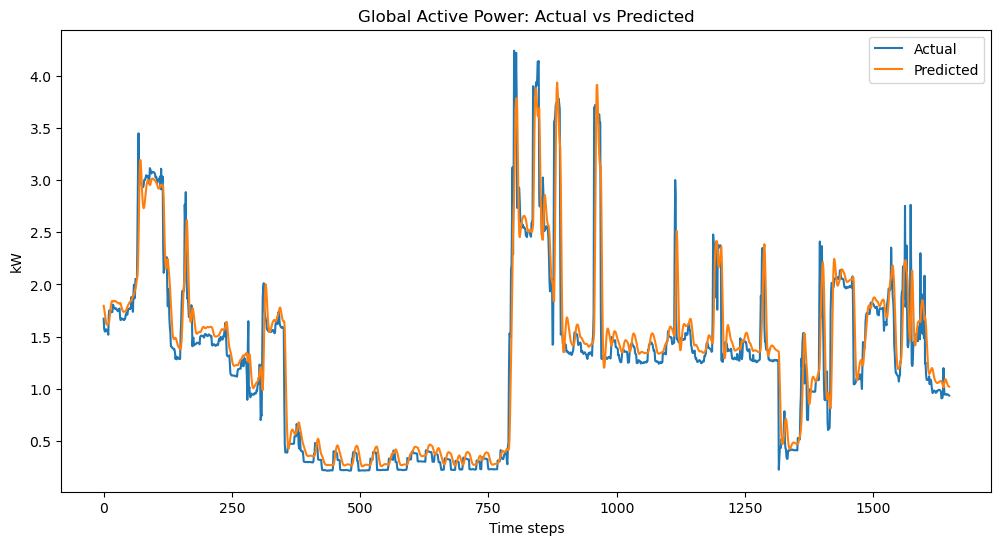

In [40]:
# Plot predicted vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.legend()
plt.title('Global Active Power: Actual vs Predicted')
plt.xlabel('Time steps')
plt.ylabel('kW')
plt.show()

In [41]:
#PROPHET
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
#prophet's 2 cols
prophet_df = df[['timestamp', 'Global_active_power']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

In [51]:
#subsampling like we did in lstm above
prophet_df = prophet_df.tail(5000)

In [52]:
#train/test split
train_size = int(len(prophet_df) * 0.65)
train = prophet_df[:train_size]
test = prophet_df[train_size:]

In [53]:
# Fit
model = Prophet()
model.fit(train)

14:58:20 - cmdstanpy - INFO - Chain [1] start processing
14:58:22 - cmdstanpy - INFO - Chain [1] done processing


In [54]:
#forecast for the length of the test set
future = model.make_future_dataframe(periods=len(test), freq='min')  # adjust freq to data's interval
forecast = model.predict(future)

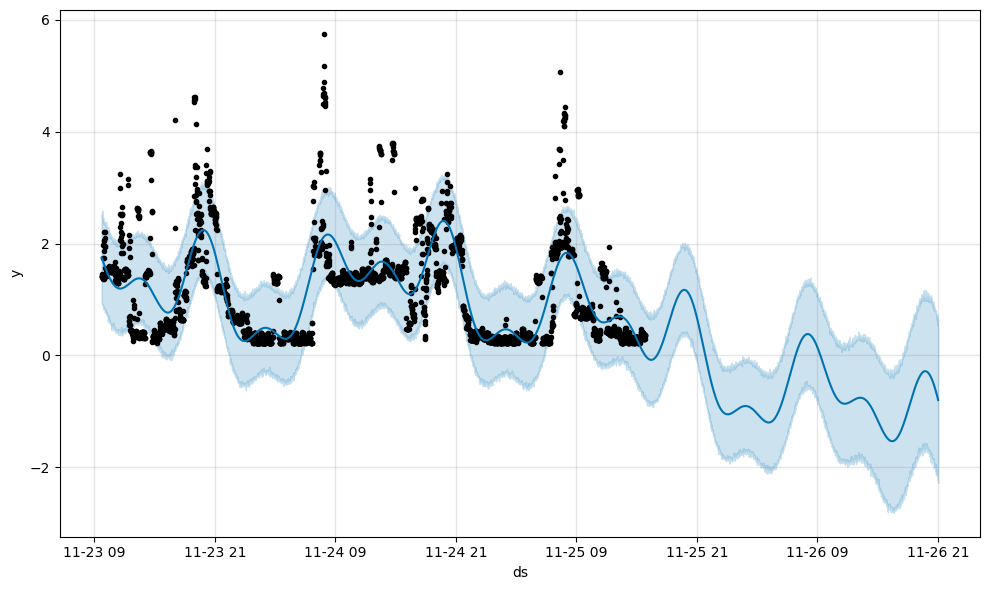

In [55]:
# Plot
fig = model.plot(forecast)
plt.show()

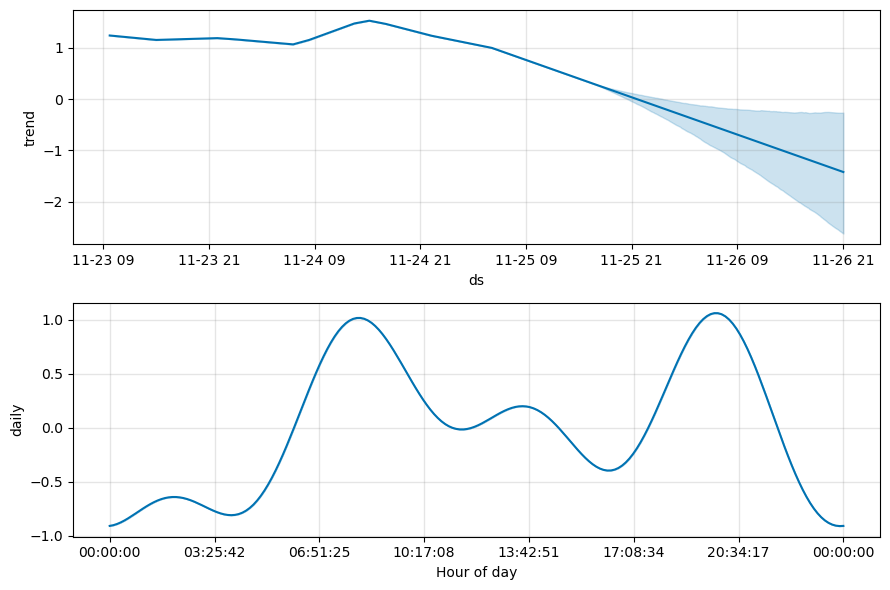

In [56]:
fig2 = model.plot_components(forecast)
plt.show()

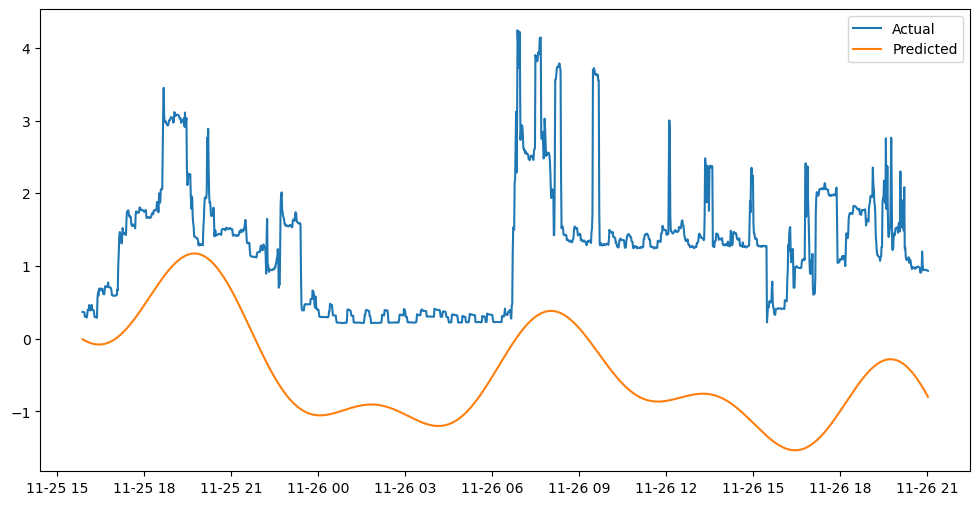

In [58]:
import matplotlib.pyplot as plt

merged = forecast[['ds','yhat']].merge(test, on='ds')
plt.figure(figsize=(12,6))
plt.plot(merged['ds'], merged['y'], label='Actual')
plt.plot(merged['ds'], merged['yhat'], label='Predicted')
plt.legend()
plt.show()

In [61]:
#XGBOOST
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 1.0/101.7 MB 949.8 kB/s eta 0:01:46
    --------------------------------------- 1.3/101.7 MB 894.7 kB/s eta 0:01:53
    --------------------------------------- 1.3/101.7 MB 894.7 kB/s eta 0:01:53
    --------------------------------------- 1.6/101.7 MB 892.3 kB/s eta 0:01:53
    --------------------------------------- 1.8/101.7 MB 875.3 kB/s eta 0:01:55
    --------------------------------------- 2.4/101.7 MB 1.0 MB/s eta 0:01:40
   - 

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [63]:
data = df[['timestamp', 'Global_active_power']].copy()
data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data.set_index('timestamp')

In [64]:
#subsample-same as before
data = data.tail(5000)

In [65]:
#Feature engineering
data['lag_1'] = data['Global_active_power'].shift(1)
data['lag_24'] = data['Global_active_power'].shift(24)
data['rolling_mean_24'] = data['Global_active_power'].rolling(24).mean()
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek

In [66]:
data = data.dropna()#dropping rows from shifting

In [67]:
train_size = int(len(data) * 0.65)
train = data[:train_size]
test = data[train_size:]

In [68]:
features = ['lag_1', 'lag_24', 'rolling_mean_24', 'hour', 'day_of_week']
X_train, y_train = train[features], train['Global_active_power']
X_test, y_test = test[features], test['Global_active_power']

In [69]:
#train
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [70]:
#Predict
predictions = model.predict(X_test)

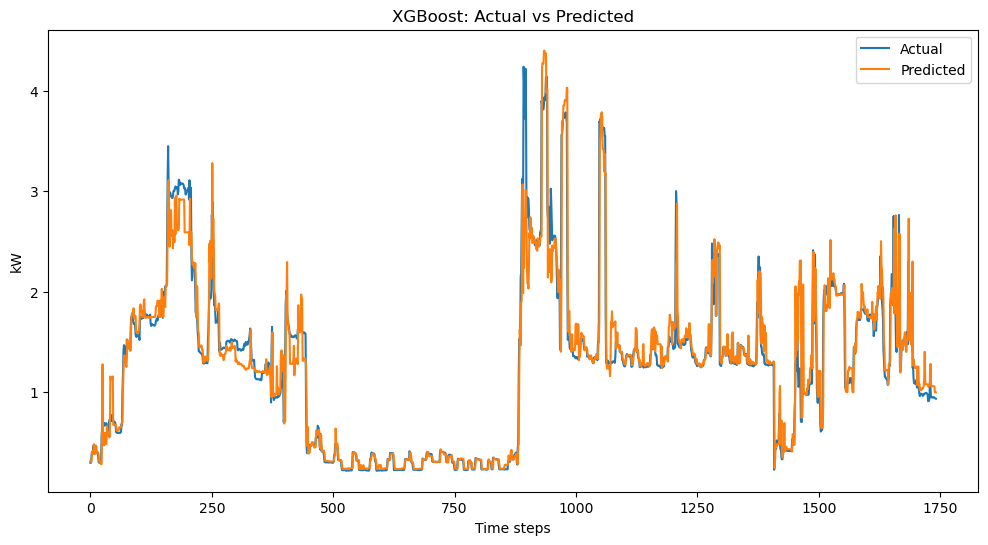

In [71]:
#here comes the plot
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Time steps')
plt.ylabel('kW')
plt.show()


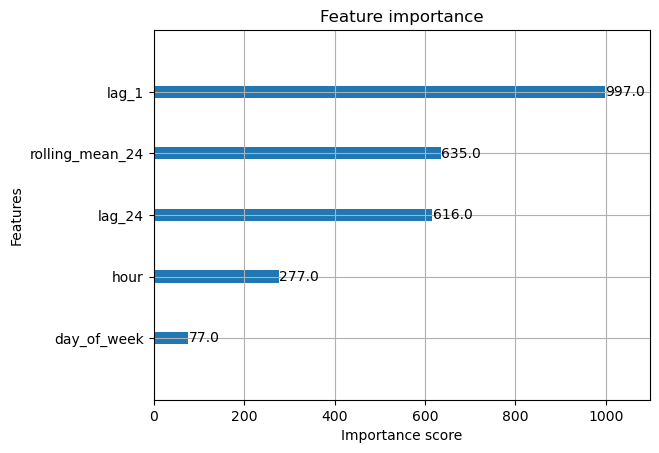

In [72]:
#feature importance(uselful if we end up choosing this model)
import xgboost as xgb
xgb.plot_importance(model)
plt.show()